### ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import polars as pl

df = pl.read_csv('cleaned_ecommerce_data.csv')

In [ ]:
df['Is Fraudulent'].value_counts()

AttributeError: 'DataFrame' object has no attribute 'Is_Fraudulent'

### VẼ BIỂU ĐỒ THỂ HIỆN TƯƠNG QUAN GIỮA TRANSACTION ID và CUSTOMER ID

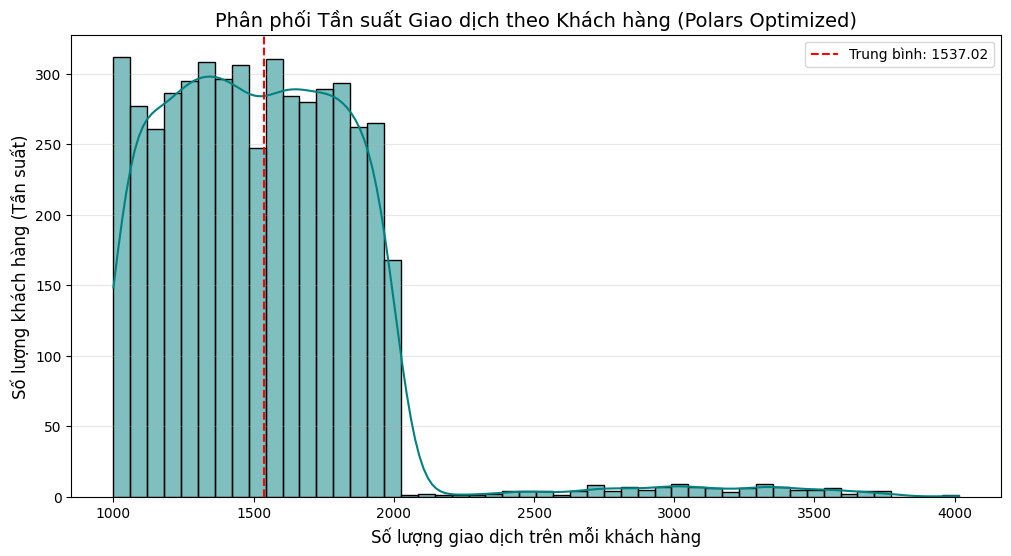

In [4]:
# 1. Nhóm và đếm bằng Polars (Xử lý cực nhanh trên 4.3 GB)
customer_counts = (
    df.group_by("Customer ID")
    .agg(
        pl.col("Transaction ID").count().alias("Transaction_Count")
    )
    .sort("Transaction_Count", descending=True)
)

# 2. Tính toán giá trị trung bình (Mean) trực tiếp từ Polars Series
mean_val = customer_counts["Transaction_Count"].mean()

# 3. Chuyển kết quả đã thu gọn sang Pandas ĐỂ VẼ BIỂU ĐỒ
# (Lúc này dữ liệu đã nhỏ vì mỗi khách hàng chỉ còn 1 dòng, không lo tốn RAM)
plot_df = customer_counts.to_pandas()

# 4. Vẽ biểu đồ Phân phối (Histogram) bằng Seaborn
plt.figure(figsize=(12, 6))
sns.histplot(data=plot_df, x='Transaction_Count', bins=50, kde=True, color='teal')

# Thêm đường trung bình (Mean) để nhận diện Outliers
plt.axvline(mean_val, color='red', linestyle='--', label=f'Trung bình: {mean_val:.2f}')

plt.title('Phân phối Tần suất Giao dịch theo Khách hàng (Polars Optimized)', fontsize=14)
plt.xlabel('Số lượng giao dịch trên mỗi khách hàng', fontsize=12)
plt.ylabel('Số lượng khách hàng (Tần suất)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### PHÂN TÍCH DỰA TRÊN GIAN LẬN THEO LOẠI THIẾT BỊ (Device Analysis)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15220\2227634325.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


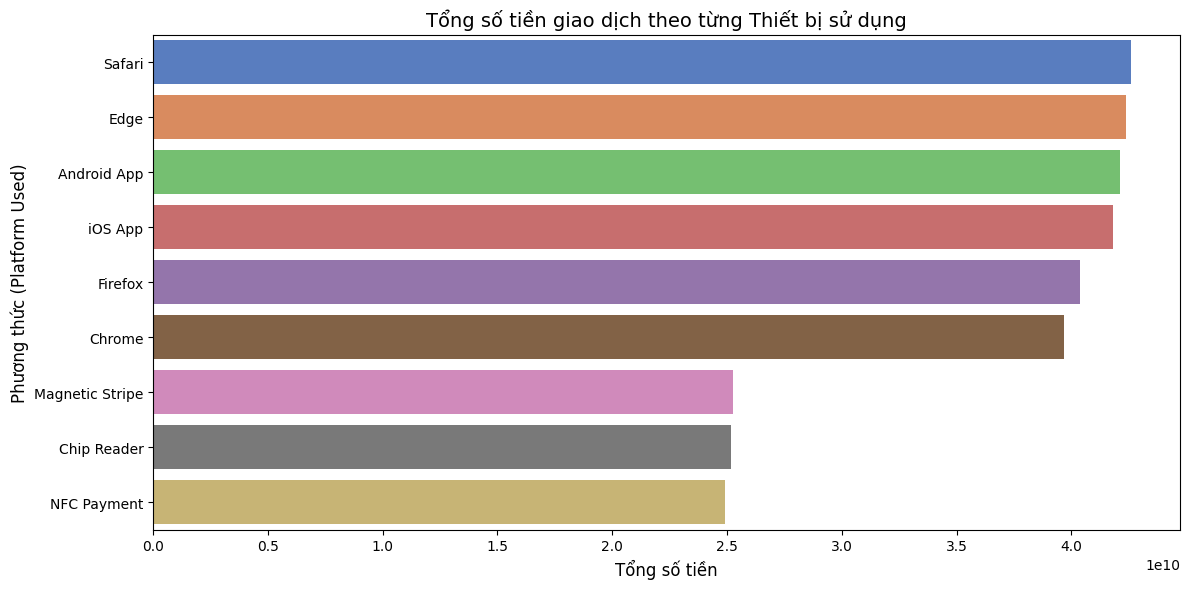

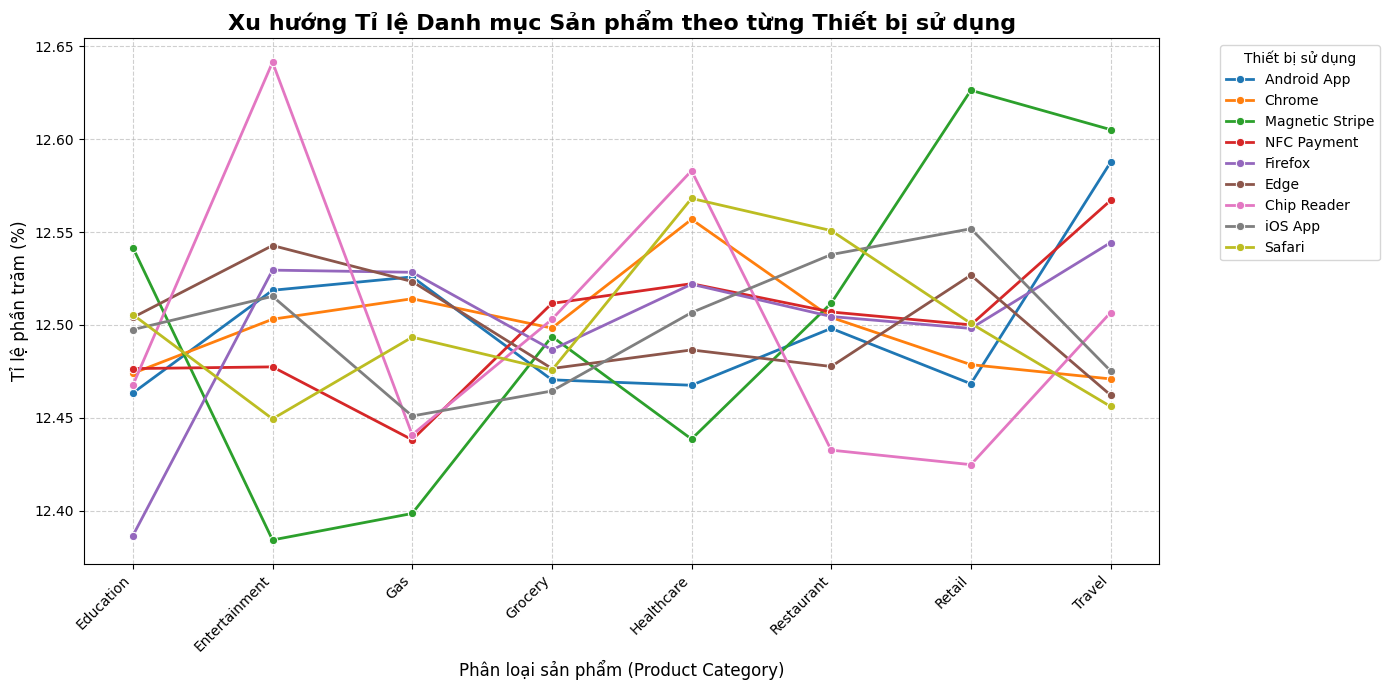

In [5]:
# 1. Tính toán bằng Polars
device_amount_stats = (
    df.group_by("Platform Used")
    .agg([
        pl.col("Amount USD").sum().alias("sum"),
        pl.col("Amount USD").mean().alias("mean")
    ])
    .sort("sum", descending=True)
)

# 2. Vẽ biểu đồ (Chuyển sang Pandas ở bước cuối cùng)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=device_amount_stats.to_pandas(), 
    x='sum', 
    y='Platform Used', 
    palette='muted'
)

plt.title('Tổng số tiền giao dịch theo từng Thiết bị sử dụng', fontsize=14)
plt.xlabel('Tổng số tiền', fontsize=12)
plt.ylabel('Phương thức (Platform Used)', fontsize=12)
plt.tight_layout()
plt.show()
device_product_counts = (
    df.group_by(["Platform Used", "Product Category"])
    .len(name="Transaction Count") # Thay thế cho .size()
    .with_columns(
        # Tính %: Lấy Count chia cho tổng Count của từng Platform
        (pl.col("Transaction Count") / pl.col("Transaction Count").sum().over("Platform Used") * 100)
        .alias("Percentage (%)")
    )
    .sort("Product Category", descending=False)
)

# 2. Vẽ biểu đồ đường
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=device_product_counts.to_pandas(), 
    x='Product Category', 
    y='Percentage (%)', 
    hue='Platform Used', 
    marker='o', 
    linewidth=2
)

plt.title('Xu hướng Tỉ lệ Danh mục Sản phẩm theo từng Thiết bị sử dụng', fontsize=16, fontweight='bold')
plt.xlabel('Phân loại sản phẩm (Product Category)', fontsize=12)
plt.ylabel('Tỉ lệ phần trăm (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Di chuyển chú thích ra ngoài
plt.legend(title='Thiết bị sử dụng', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15220\1307483238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Product Category', y='Amount USD', palette='Blues_d', errorbar=None)


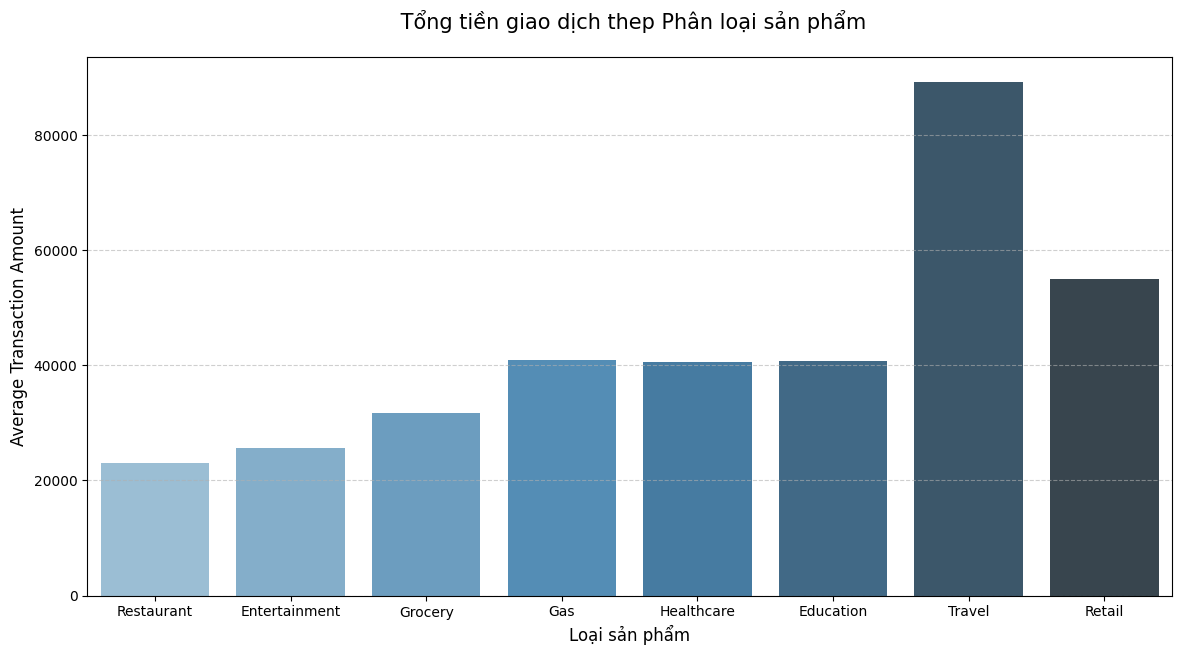

In [6]:

plt.figure(figsize = (14,7))
ax = sns.barplot(data=df, x='Product Category', y='Amount USD', palette='Blues_d', errorbar=None)
plt.title(' Tổng tiền giao dịch thep Phân loại sản phẩm', fontsize=15, pad=20)
plt.xlabel('Loại sản phẩm', fontsize=12)
plt.ylabel('Average Transaction Amount', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15220\2383560380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Amount USD', y='Merchant Type', palette='Blues_d', errorbar=None)


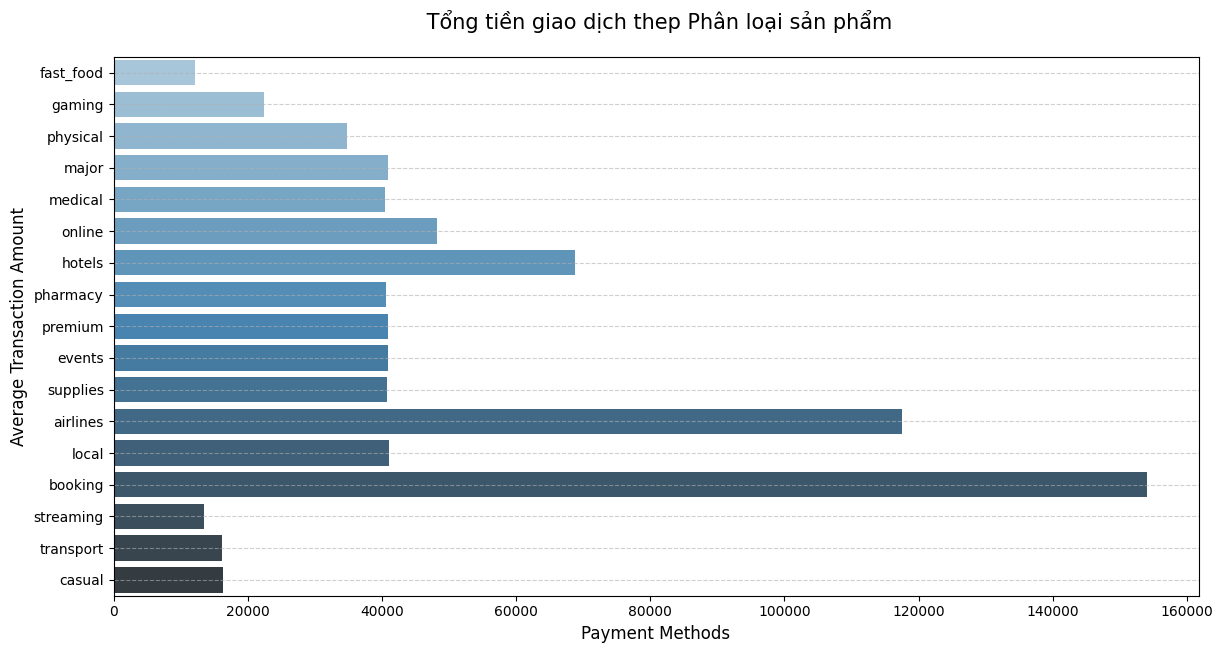

In [7]:
# Biểu đồ cột giữa payment methods và transaction amount 
plt.figure(figsize = (14,7))
sns.barplot(data=df, x='Amount USD', y='Merchant Type', palette='Blues_d', errorbar=None)
plt.title(' Tổng tiền giao dịch thep Phân loại sản phẩm', fontsize=15, pad=20)
plt.xlabel('Payment Methods', fontsize=12)
plt.ylabel('Average Transaction Amount', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

### PHÂN TÍCH THEO ĐỊA CHỈ IP VÀ ĐỊA ĐIỂM MUA HÀNG 

In [8]:
df['Is_IP_Country_Mismatch'].value_counts()

Is_IP_Country_Mismatch,count
i64,u32
0,101449
1,7382317


C:\Users\Admin\AppData\Local\Temp\ipykernel_14424\866200864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Is_IP_Country_Mismatch', palette='Blues_d')


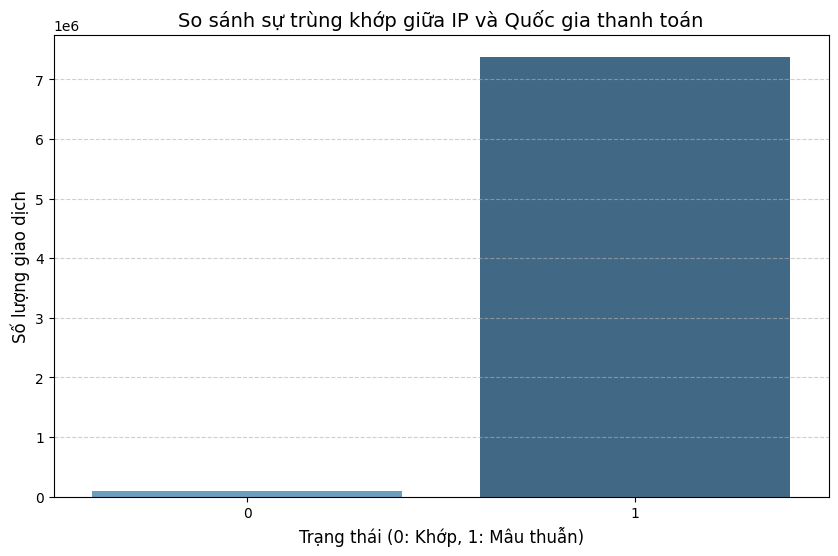

In [2]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Is_IP_Country_Mismatch', palette='Blues_d')

plt.title('So sánh sự trùng khớp giữa IP và Quốc gia thanh toán', fontsize=14)
plt.xlabel('Trạng thái (0: Khớp, 1: Mâu thuẫn)', fontsize=12)
plt.ylabel('Số lượng giao dịch', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

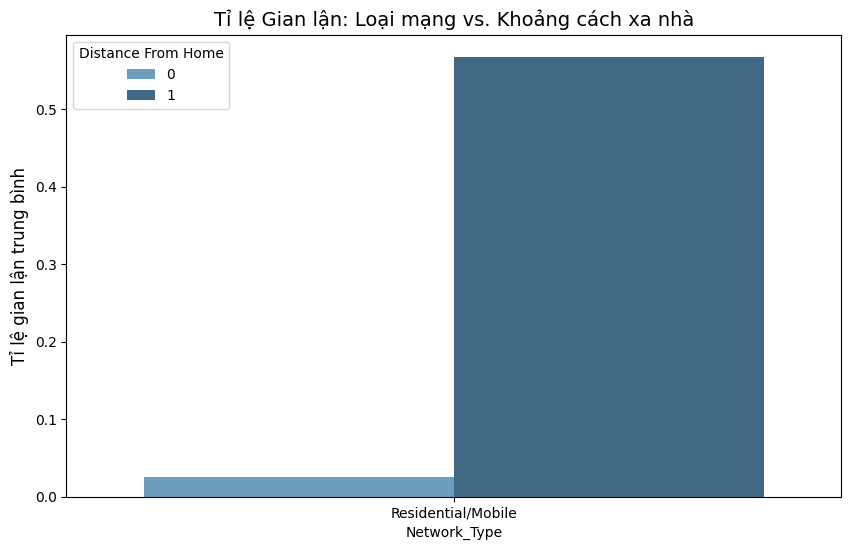

In [3]:
# 1. Phân loại IP dựa trên số người dùng (Proxy/Data Center vs Residential)
network_analysis = (
    df.with_columns(
        pl.col("Customer ID").n_unique().over("IP Address").alias("IP_Users")
    ).with_columns(
        pl.when(pl.col("IP_Users") > 10).then(pl.lit("Data Center/Proxy"))
        .otherwise(pl.lit("Residential/Mobile")).alias("Network_Type")
    )
)

# 2. Tính tỉ lệ gian lận theo Network Type và Distance From Home
dist_net_stats = (
    network_analysis.group_by(["Network_Type", "Distance From Home"])
    .agg(pl.col("Is Fraudulent").mean().alias("Fraud_Rate"))
)

# 3. Vẽ biểu đồ cột nhóm
plt.figure(figsize=(10, 6))
sns.barplot(
    data=dist_net_stats.to_pandas(), 
    x="Network_Type", 
    y="Fraud_Rate", 
    hue="Distance From Home", 
    palette="Blues_d"
)

plt.title("Tỉ lệ Gian lận: Loại mạng vs. Khoảng cách xa nhà", fontsize=14)
plt.ylabel("Tỉ lệ gian lận trung bình", fontsize=12)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14424\1910825932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


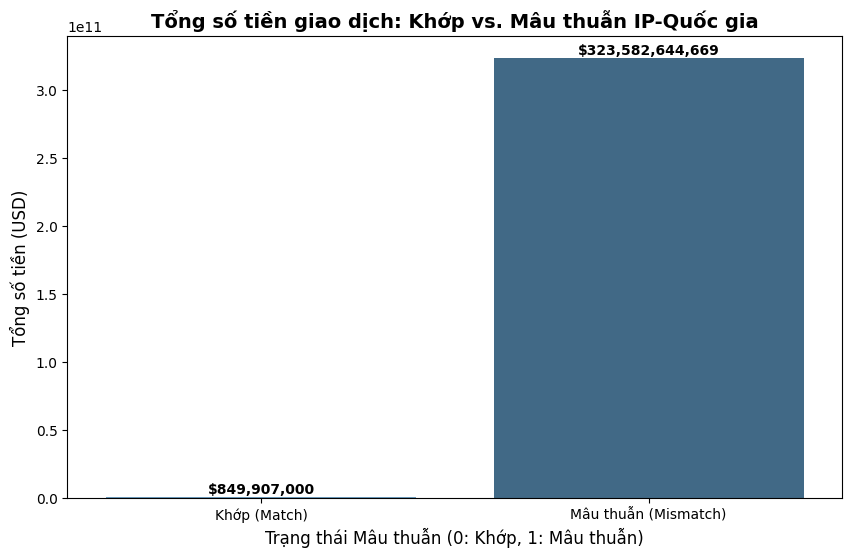

In [4]:

# 1. Tính tổng số tiền (Amount USD) theo trạng thái Mismatch
# 0: Khớp quốc gia, 1: Mâu thuẫn quốc gia
mismatch_amount_stats = (
    df.group_by("Is_IP_Country_Mismatch")
    .agg(
        pl.col("Amount USD").sum().alias("Total_Amount")
    )
    .sort("Is_IP_Country_Mismatch")
)

# 2. Chuyển sang Pandas để vẽ biểu đồ
plot_df = mismatch_amount_stats.to_pandas()

# 3. Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df, 
    x='Is_IP_Country_Mismatch', 
    y='Total_Amount', 
    palette='Blues_d' # Xanh cho an toàn, Đỏ cho nguy cơ
)

# Định dạng biểu đồ
plt.title('Tổng số tiền giao dịch: Khớp vs. Mâu thuẫn IP-Quốc gia', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái Mâu thuẫn (0: Khớp, 1: Mâu thuẫn)', fontsize=12)
plt.ylabel('Tổng số tiền (USD)', fontsize=12)
plt.xticks([0, 1], ['Khớp (Match)', 'Mâu thuẫn (Mismatch)'])
# Thêm nhãn giá trị trên đầu cột
for i, val in enumerate(plot_df['Total_Amount']):
    plt.text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

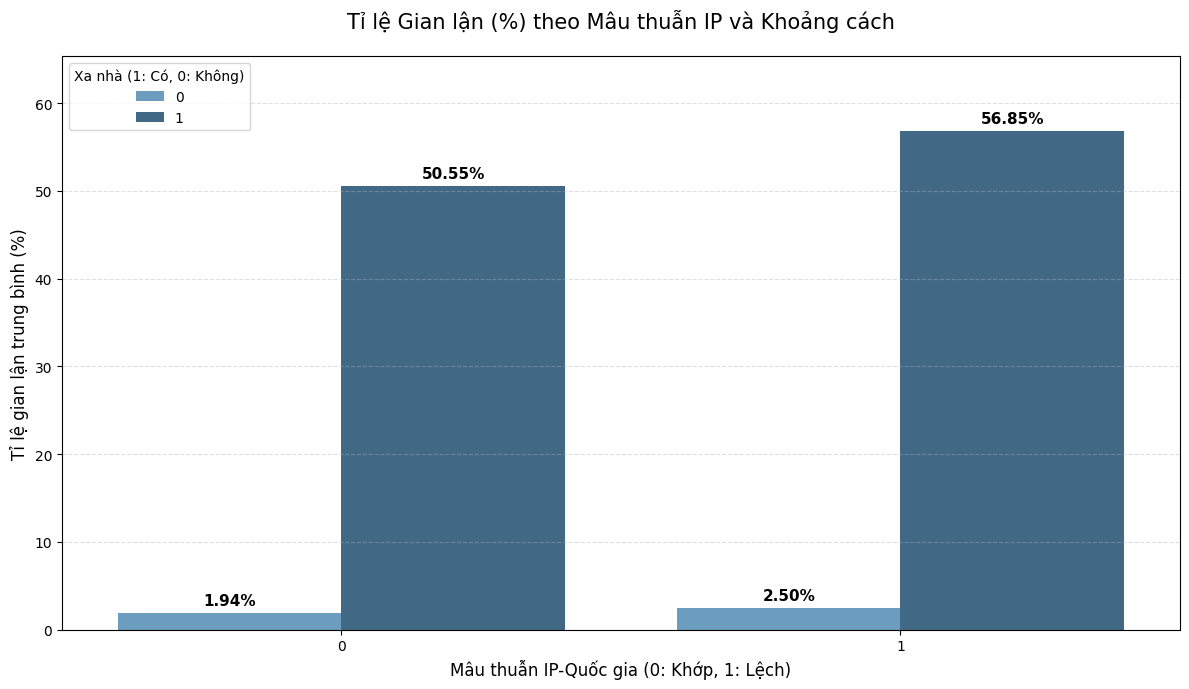

In [5]:


# 1. Tính toán tỉ lệ gian lận bằng Polars
location_risk = (
    df.group_by(["Is_IP_Country_Mismatch", "Distance From Home"])
    .agg(
        (pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate")
    )
    .sort("Is_IP_Country_Mismatch")
)

# 2. Chuyển sang Pandas để vẽ
plot_df = location_risk.to_pandas()

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_df, 
    x='Is_IP_Country_Mismatch', 
    y='Fraud_Rate', 
    hue='Distance From Home', 
    palette='Blues_d' # Đỏ cho rủi ro cao, Xanh cho rủi ro thấp
)

# --- PHẦN THÊM NHÃN GIÁ TRỊ ---
for p in ax.patches:
    if p.get_height() > 0: # Chỉ hiện nhãn nếu giá trị > 0
        ax.annotate(
            format(p.get_height(), '.2f') + '%', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 9), 
            textcoords='offset points',
            fontsize=11,
            fontweight='bold'
        )

# 4. Định dạng biểu đồ
plt.title('Tỉ lệ Gian lận (%) theo Mâu thuẫn IP và Khoảng cách', fontsize=15, pad=20)
plt.xlabel('Mâu thuẫn IP-Quốc gia (0: Khớp, 1: Lệch)', fontsize=12)
plt.ylabel('Tỉ lệ gian lận trung bình (%)', fontsize=12)
plt.ylim(0, plot_df['Fraud_Rate'].max() * 1.15) # Tạo khoảng trống phía trên để hiện nhãn
plt.legend(title='Xa nhà (1: Có, 0: Không)', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14424\2173805889.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


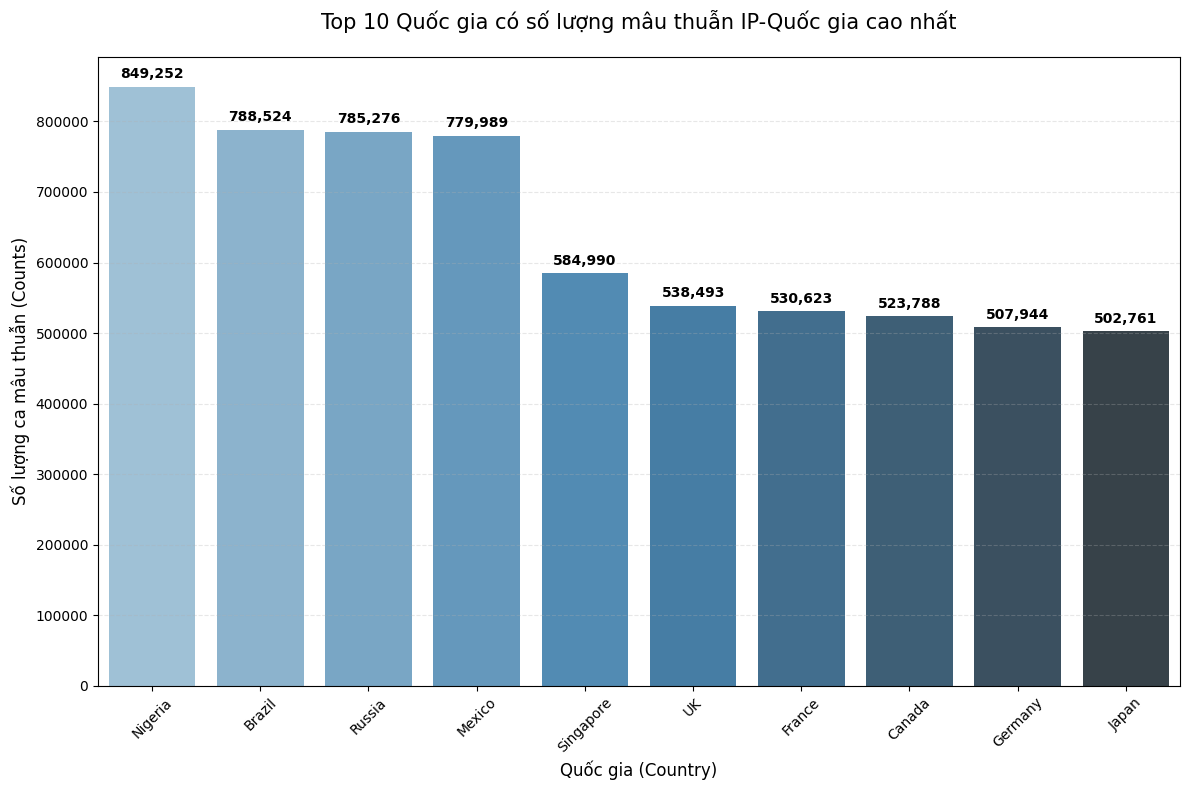

In [6]:

# 1. Lọc các bản ghi bị mâu thuẫn và đếm theo Country
top_mismatch_countries = (
    df.filter(pl.col("Is_IP_Country_Mismatch") == 1)
    .group_by("Country")
    .agg(pl.len().alias("Mismatch_Count"))
    .sort("Mismatch_Count", descending=True)
    .head(10) # Lấy Top 10 để biểu đồ rõ ràng
)

# 2. Chuyển sang Pandas để vẽ
plot_df = top_mismatch_countries.to_pandas()

# 3. Vẽ biểu đồ cột đứng
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=plot_df, 
    x='Country', 
    y='Mismatch_Count', 
    palette='Blues_d'
)

# --- THÊM NHÃN GIÁ TRỊ TRÊN CỘT ---
for p in ax.patches:
    ax.annotate(
        format(int(p.get_height()), ','), # Định dạng số có dấu phẩy (ví dụ: 1,000)
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# 4. Định dạng biểu đồ
plt.title('Top 10 Quốc gia có số lượng mâu thuẫn IP-Quốc gia cao nhất', fontsize=15, pad=20)
plt.xlabel('Quốc gia (Country)', fontsize=12)
plt.ylabel('Số lượng ca mâu thuẫn (Counts)', fontsize=12)
plt.xticks(rotation=45) # Xoay tên quốc gia nếu quá dài
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### PHÂN TÍCH THEO CHUỖI THỜI GIAN

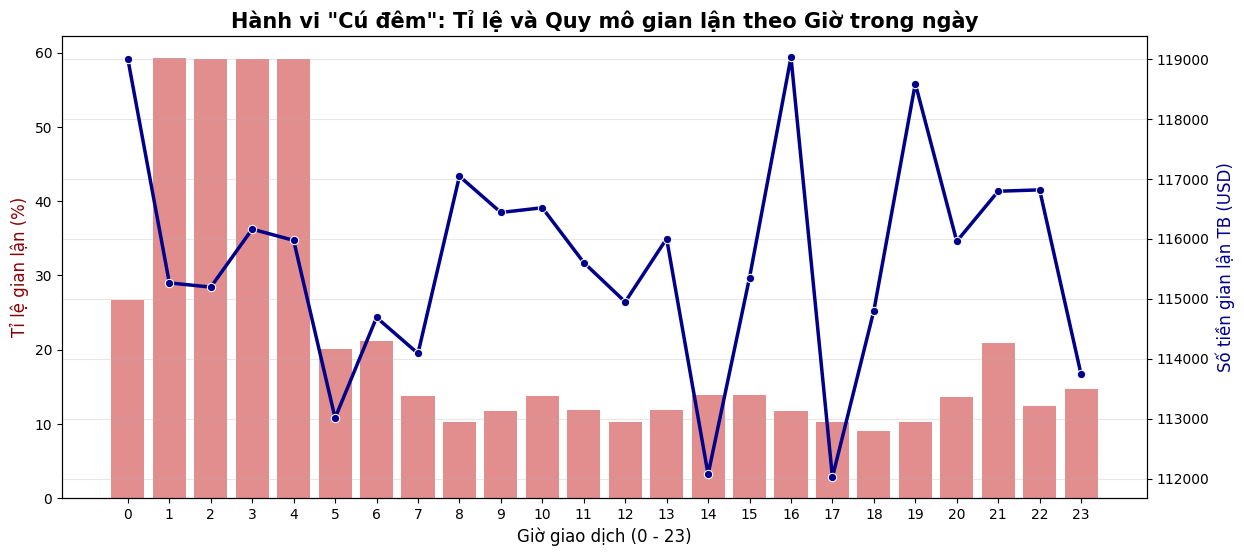

In [7]:

# Tính Tỉ lệ gian lận và Số tiền trung bình theo từng Giờ
hourly_stats = (
    df.group_by("Transaction Hour")
    .agg([
        (pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate_%"),
        pl.col("Amount USD").filter(pl.col("Is Fraudulent") == 1).mean().alias("Avg_Fraud_Amount")
    ])
    .sort("Transaction Hour")
)

plot_df = hourly_stats.to_pandas()

# Vẽ biểu đồ 2 trục Y (Dual Y-Axis)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1: Tỉ lệ gian lận (Bar chart)
sns.barplot(data=plot_df, x='Transaction Hour', y='Fraud_Rate_%', color='lightcoral', ax=ax1)
ax1.set_ylabel('Tỉ lệ gian lận (%)', color='darkred', fontsize=12)
ax1.set_xlabel('Giờ giao dịch (0 - 23)', fontsize=12)

# Trục 2: Số tiền gian lận trung bình (Line chart)
ax2 = ax1.twinx()
sns.lineplot(data=plot_df, x='Transaction Hour', y='Avg_Fraud_Amount', color='darkblue', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Số tiền gian lận TB (USD)', color='darkblue', fontsize=12)

plt.title('Hành vi "Cú đêm": Tỉ lệ và Quy mô gian lận theo Giờ trong ngày', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df.shape

(7483766, 32)

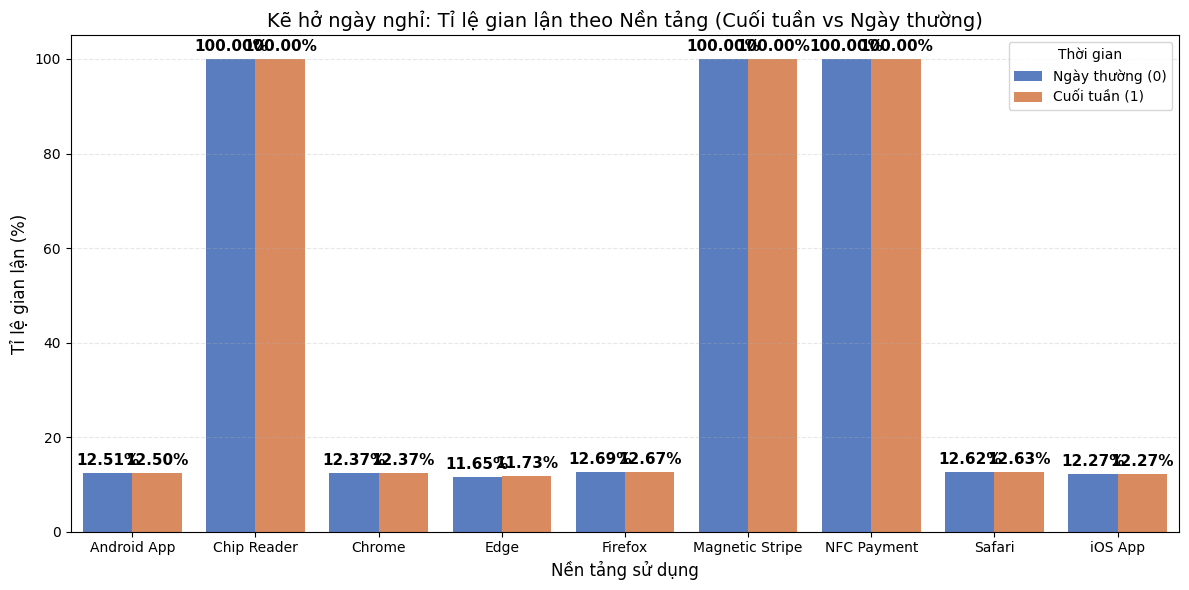

In [8]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính Tỉ lệ gian lận theo Nền tảng và Cuối tuần
weekend_analysis = (
    df.group_by(["Platform Used", "Weekend Transaction"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
    .sort("Platform Used", "Weekend Transaction")
)

plot_df3 = weekend_analysis.to_pandas()

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))

# SỬA LỖI TẠI ĐÂY: Gán biểu đồ vào biến 'ax'
ax = sns.barplot(
    data=plot_df3, 
    x='Platform Used', 
    y='Fraud_Rate', 
    hue='Weekend Transaction', 
    palette='muted'
)

# Thêm nhãn giá trị trên đầu cột
for p in ax.patches:
    if p.get_height() > 0: # Chỉ hiện nhãn nếu giá trị > 0
        ax.annotate(
            format(p.get_height(), '.2f') + '%', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 9), 
            textcoords='offset points',
            fontsize=11,
            fontweight='bold'
        )

# 3. Định dạng biểu đồ
plt.title('Kẽ hở ngày nghỉ: Tỉ lệ gian lận theo Nền tảng (Cuối tuần vs Ngày thường)', fontsize=14)
plt.xlabel('Nền tảng sử dụng', fontsize=12)
plt.ylabel('Tỉ lệ gian lận (%)', fontsize=12)

# Đổi tên chú thích cho dễ hiểu
handles, _ = ax.get_legend_handles_labels()
plt.legend(
    handles=handles, 
    title='Thời gian', 
    labels=['Ngày thường (0)', 'Cuối tuần (1)'],
    loc='upper right' # Bạn có thể đổi vị trí nếu nó đè lên cột
)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout() # Căn chỉnh tự động để biểu đồ gọn gàng hơn
plt.show()

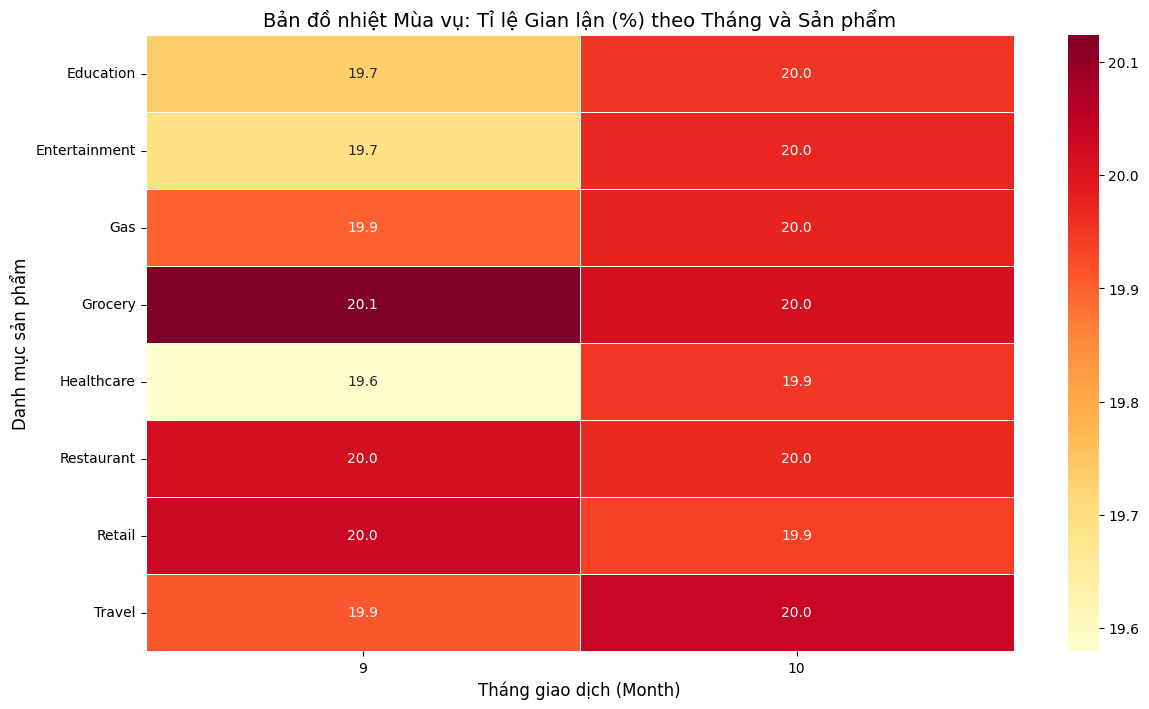

In [9]:
# 1. Tính Tỉ lệ gian lận theo Tháng và Danh mục sản phẩm
season_analysis = (
    df.group_by(["Transaction Month", "Product Category"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
)

# 2. Tạo Pivot Table bằng Pandas để vẽ Heatmap
heatmap_data = season_analysis.to_pandas().pivot(
    index="Product Category", 
    columns="Transaction Month", 
    values="Fraud_Rate"
)

# 3. Vẽ Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=.5)

plt.title('Bản đồ nhiệt Mùa vụ: Tỉ lệ Gian lận (%) theo Tháng và Sản phẩm', fontsize=14)
plt.xlabel('Tháng giao dịch (Month)', fontsize=12)
plt.ylabel('Danh mục sản phẩm', fontsize=12)
plt.show()

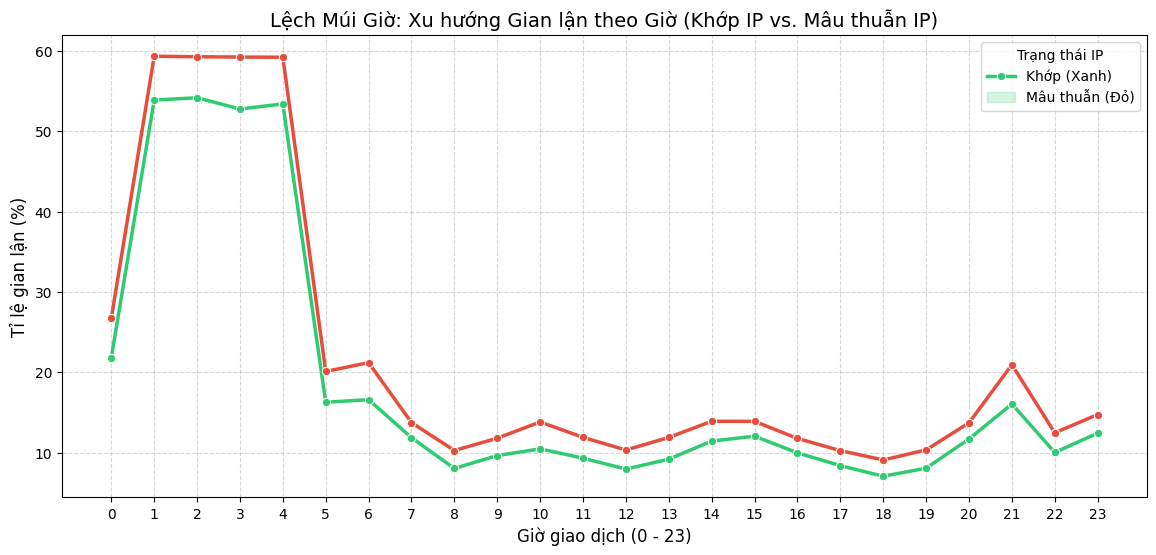

In [10]:
# 1. Tính Tỉ lệ gian lận theo Giờ và Trạng thái Mismatch IP
timezone_analysis = (
    df.group_by(["Transaction Hour", "Is_IP_Country_Mismatch"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
    .sort("Transaction Hour")
)

plot_df5 = timezone_analysis.to_pandas()

# 2. Vẽ biểu đồ đường để thấy xu hướng thời gian
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=plot_df5, 
    x='Transaction Hour', 
    y='Fraud_Rate', 
    hue='Is_IP_Country_Mismatch', 
    marker='o', 
    linewidth=2.5,
    palette=['#2ECC71', '#E74C3C'] # Xanh (Khớp) - Đỏ (Mâu thuẫn)
)

plt.title('Lệch Múi Giờ: Xu hướng Gian lận theo Giờ (Khớp IP vs. Mâu thuẫn IP)', fontsize=14)
plt.xlabel('Giờ giao dịch (0 - 23)', fontsize=12)
plt.ylabel('Tỉ lệ gian lận (%)', fontsize=12)
plt.legend(title='Trạng thái IP', labels=['Khớp (Xanh)', 'Mâu thuẫn (Đỏ)'])
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

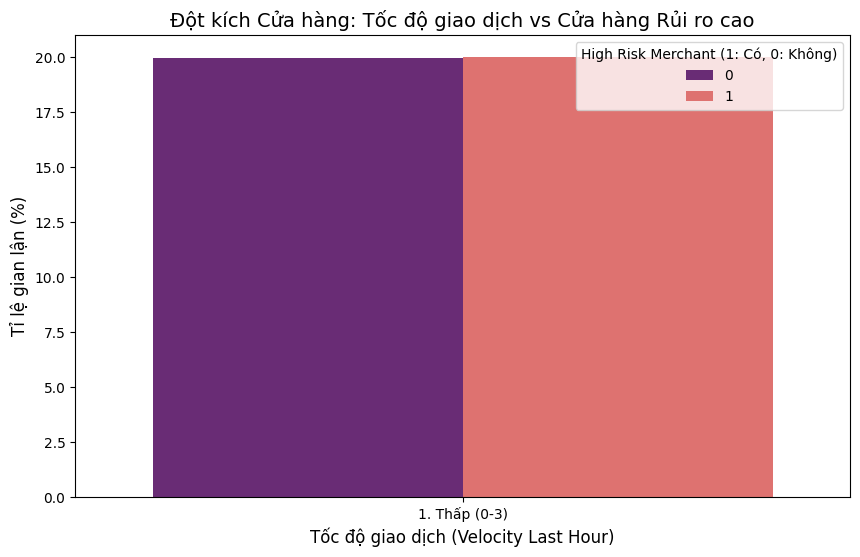

In [11]:
# 1. Chia nhóm Tốc độ giao dịch (Velocity Bins)
smash_analysis = (
    df.with_columns(
        pl.when(pl.col("Velocity Last Hour") <= 3).then(pl.lit("1. Thấp (0-3)"))
        .when(pl.col("Velocity Last Hour") <= 8).then(pl.lit("2. Vừa (4-8)"))
        .otherwise(pl.lit("3. Cao (>8)")).alias("Velocity_Bin")
    )
    .group_by(["Velocity_Bin", "High Risk Merchant"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
    .sort("Velocity_Bin")
)

plot_df6 = smash_analysis.to_pandas()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df6, 
    x='Velocity_Bin', 
    y='Fraud_Rate', 
    hue='High Risk Merchant', 
    palette='magma'
)

plt.title('Đột kích Cửa hàng: Tốc độ giao dịch vs Cửa hàng Rủi ro cao', fontsize=14)
plt.xlabel('Tốc độ giao dịch (Velocity Last Hour)', fontsize=12)
plt.ylabel('Tỉ lệ gian lận (%)', fontsize=12)
plt.legend(title='High Risk Merchant (1: Có, 0: Không)')
plt.show()

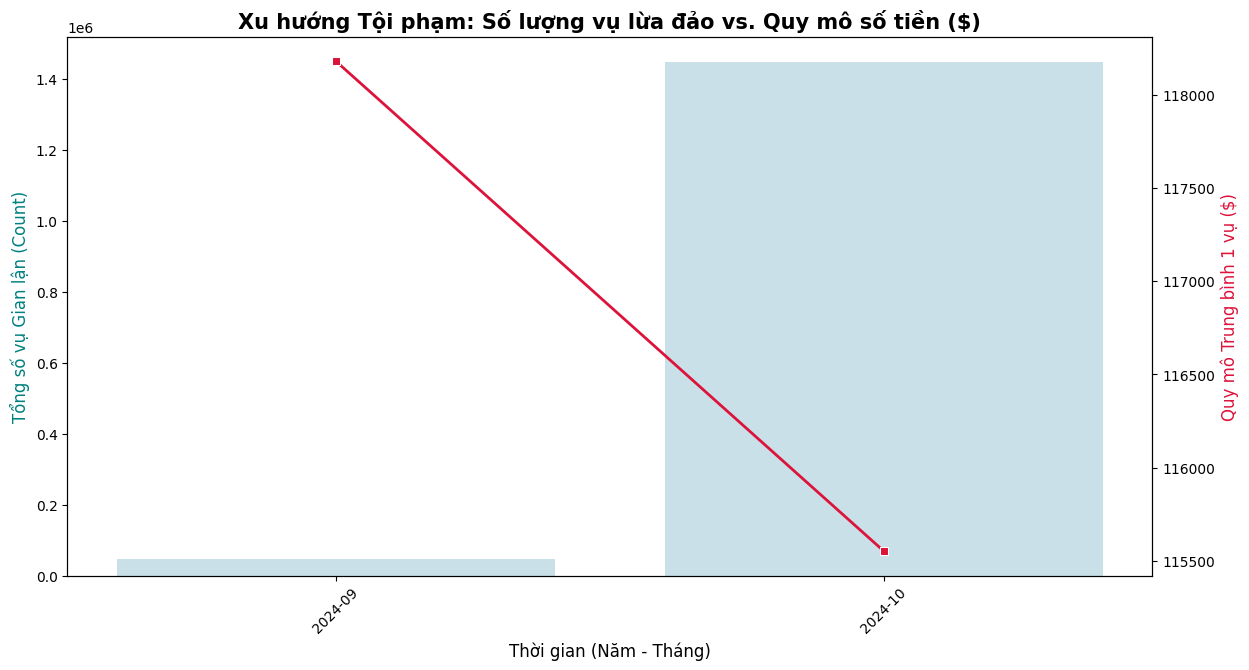

In [ ]:
# 1. Lọc CHỈ giao dịch gian lận (Is Fraudulent == 1)
# Tính tổng số vụ và giá trị trung bình mỗi vụ theo Năm-Tháng
trend_analysis = (
    df.filter(pl.col("Is Fraudulent") == 1)
    .group_by(["Transaction Year", "Transaction Month"])
    .agg([
        pl.len().alias("Fraud_Count"), # Số lượng vụ gian lận
        pl.col("Amount USD").mean().alias("Avg_Fraud_Amount") # Số tiền bị mất trung bình
    ])
    .sort(["Transaction Year", "Transaction Month"])
)

# Tạo cột Năm-Tháng (YYYY-MM) dạng chuỗi để vẽ trục X
plot_df7 = trend_analysis.to_pandas()
plot_df7['Year_Month'] = plot_df7['Transaction Year'].astype(str) + "-" + plot_df7['Transaction Month'].astype(str).str.zfill(2)

# 2. Vẽ biểu đồ 2 trục Y
fig, ax1 = plt.subplots(figsize=(14, 7))

# Trục 1: Số lượng vụ gian lận (Cột)
sns.barplot(data=plot_df7, x='Year_Month', y='Fraud_Count', color='lightblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Tổng số vụ Gian lận (Count)', color='teal', fontsize=12)
ax1.set_xlabel('Thời gian (Năm - Tháng)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Trục 2: Số tiền trung bình mỗi vụ (Đường)
ax2 = ax1.twinx()
sns.lineplot(data=plot_df7, x='Year_Month', y='Avg_Fraud_Amount', color='crimson', marker='s', linewidth=2, ax=ax2)
ax2.set_ylabel('Quy mô Trung bình 1 vụ ($)', color='crimson', fontsize=12)

plt.title('Xu hướng Tội phạm: Số lượng vụ lừa đảo vs. Quy mô số tiền ($)', fontsize=15, fontweight='bold')
plt.show()

### PHÂN TÍCH THEO VÙNG THỰC HIỆN GIAO DỊCH

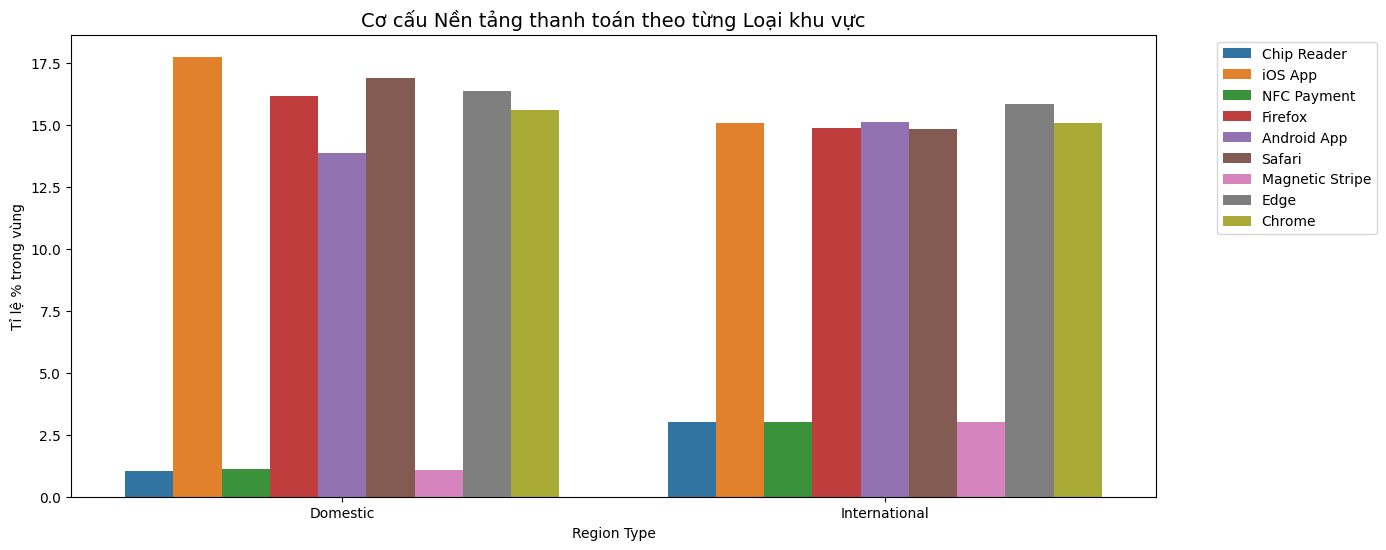

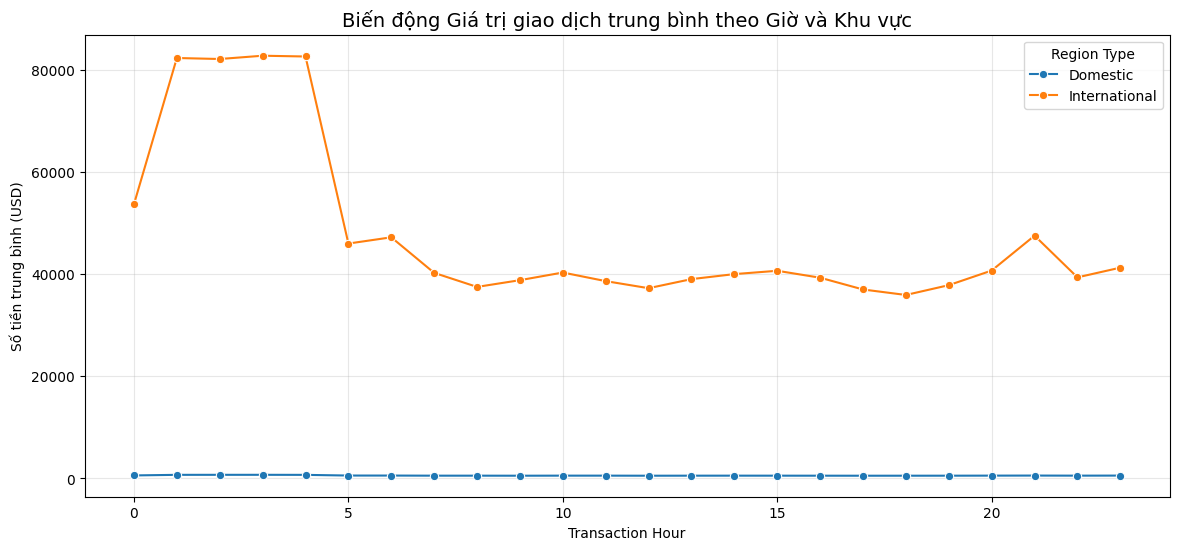

In [ ]:

# --- PHÂN TÍCH 1: Nền tảng sử dụng theo vùng ---
region_platform = (
    df.group_by(["Region Type", "Platform Used"])
    .len(name="Count")
    .with_columns(
        (pl.col("Count") / pl.col("Count").sum().over("Region Type") * 100).alias("Percentage")
    )
)

plt.figure(figsize=(14, 6))
sns.barplot(data=region_platform.to_pandas(), x='Region Type', y='Percentage', hue='Platform Used')
plt.title('Cơ cấu Nền tảng thanh toán theo từng Loại khu vực', fontsize=14)
plt.ylabel('Tỉ lệ % trong vùng')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- PHÂN TÍCH 2: Giá trị giao dịch trung bình theo vùng và Giờ ---
region_time_amount = (
    df.group_by(["Region Type", "Transaction Hour"])
    .agg(pl.col("Amount USD").mean().alias("Avg_Amount"))
    .sort("Transaction Hour")
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=region_time_amount.to_pandas(), x='Transaction Hour', y='Avg_Amount', hue='Region Type', marker='o')
plt.title('Biến động Giá trị giao dịch trung bình theo Giờ và Khu vực', fontsize=14)
plt.ylabel('Số tiền trung bình (USD)')
plt.grid(True, alpha=0.3)
plt.show()

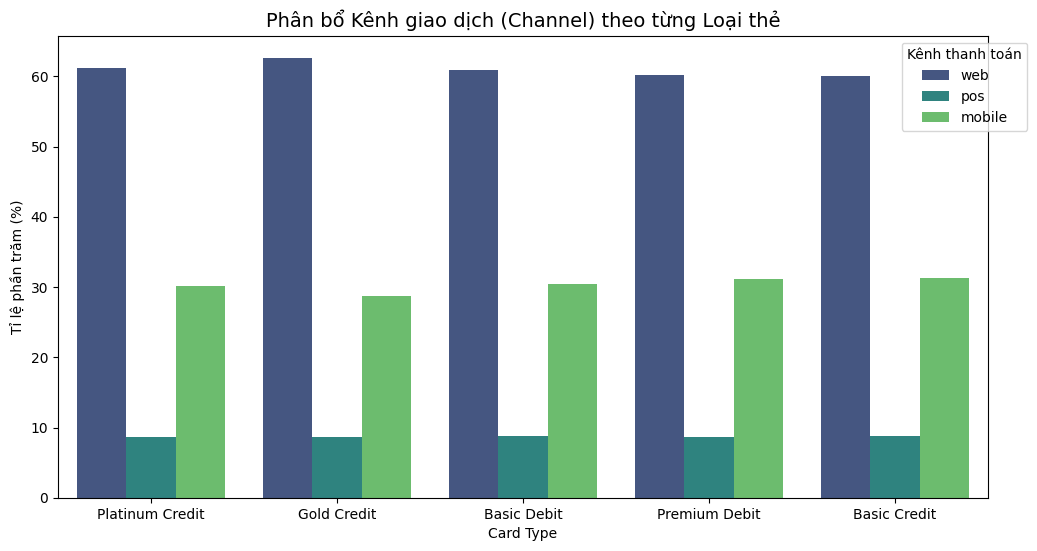

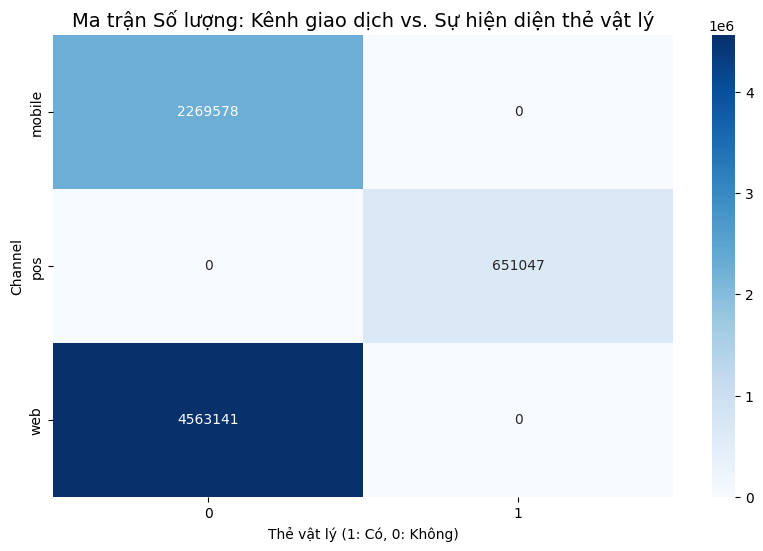

In [ ]:

# --- PHÂN TÍCH 1: Cơ cấu Kênh giao dịch theo Loại thẻ ---
card_channel_stats = (
    df.group_by(["Card Type", "Channel"])
    .len(name="Count")
    .with_columns(
        (pl.col("Count") / pl.col("Count").sum().over("Card Type") * 100).alias("Percentage")
    )
)

plt.figure(figsize=(12, 6))
sns.barplot(data=card_channel_stats.to_pandas(), x='Card Type', y='Percentage', hue='Channel', palette='viridis')
plt.title('Phân bổ Kênh giao dịch (Channel) theo từng Loại thẻ', fontsize=14)
plt.ylabel('Tỉ lệ phần trăm (%)')
plt.legend(title='Kênh thanh toán', bbox_to_anchor=(1.05, 1))
plt.show()

# --- PHÂN TÍCH 2: Ma trận Card Present vs Channel (Kiểm tra tính logic) ---
presence_matrix = (
    df.group_by(["Channel", "Card Present"])
    .len(name="Total")
    .to_pandas()
    .pivot(index="Channel", columns="Card Present", values="Total")
    .fillna(0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(presence_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title('Ma trận Số lượng: Kênh giao dịch vs. Sự hiện diện thẻ vật lý', fontsize=14)
plt.xlabel('Thẻ vật lý (1: Có, 0: Không)')
plt.show()

### PHÂN TÍCH THEO TỈ LỆ LỪA ĐẢO 

shape: (2, 4)
┌───────────────┬────────────────┬───────────────┬────────────────┐
│ Is Fraudulent ┆ Average_Amount ┆ Median_Amount ┆ Std_Dev_Amount │
│ ---           ┆ ---            ┆ ---           ┆ ---            │
│ i64           ┆ f64            ┆ f64           ┆ f64            │
╞═══════════════╪════════════════╪═══════════════╪════════════════╡
│ 0             ┆ 25311.247032   ┆ 635.04        ┆ 86232.1869     │
│ 1             ┆ 115635.315781  ┆ 4545.02       ┆ 346883.646816  │
└───────────────┴────────────────┴───────────────┴────────────────┘


C:\Users\Admin\AppData\Local\Temp\ipykernel_19104\3795461001.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x='Is Fraudulent', y='Amount USD', palette='Set1')


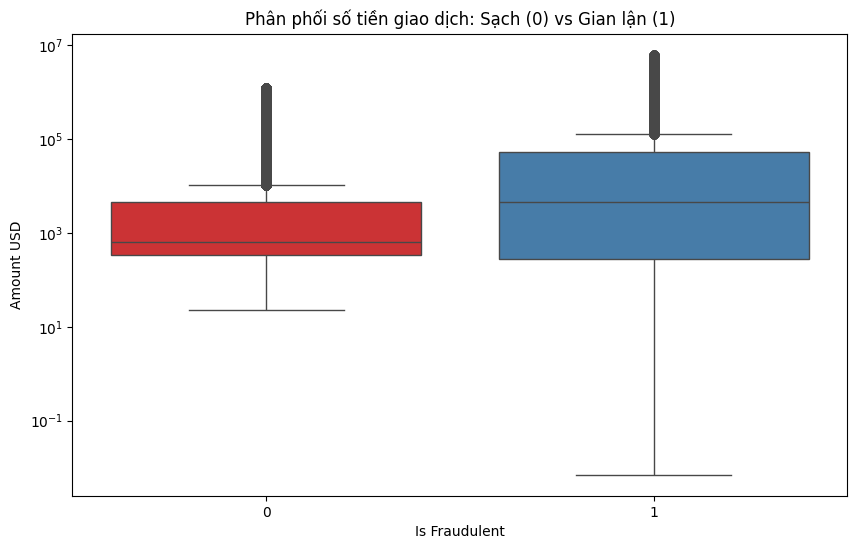

In [ ]:
# So sánh số tiền trung bình của giao dịch Sạch và Gian lận
amount_analysis = (
    df.group_by("Is Fraudulent")
    .agg(
        pl.col("Amount USD").mean().alias("Average_Amount"),
        pl.col("Amount USD").median().alias("Median_Amount"),
        pl.col("Amount USD").std().alias("Std_Dev_Amount")
    )
)

print(amount_analysis)

# Vẽ biểu đồ Boxplot để thấy rõ các điểm Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.to_pandas(), x='Is Fraudulent', y='Amount USD', palette='Set1')
plt.yscale('log') # Dùng thang đo Log vì Amount có thể chênh lệch rất lớn
plt.title('Phân phối số tiền giao dịch: Sạch (0) vs Gian lận (1)')
plt.show()

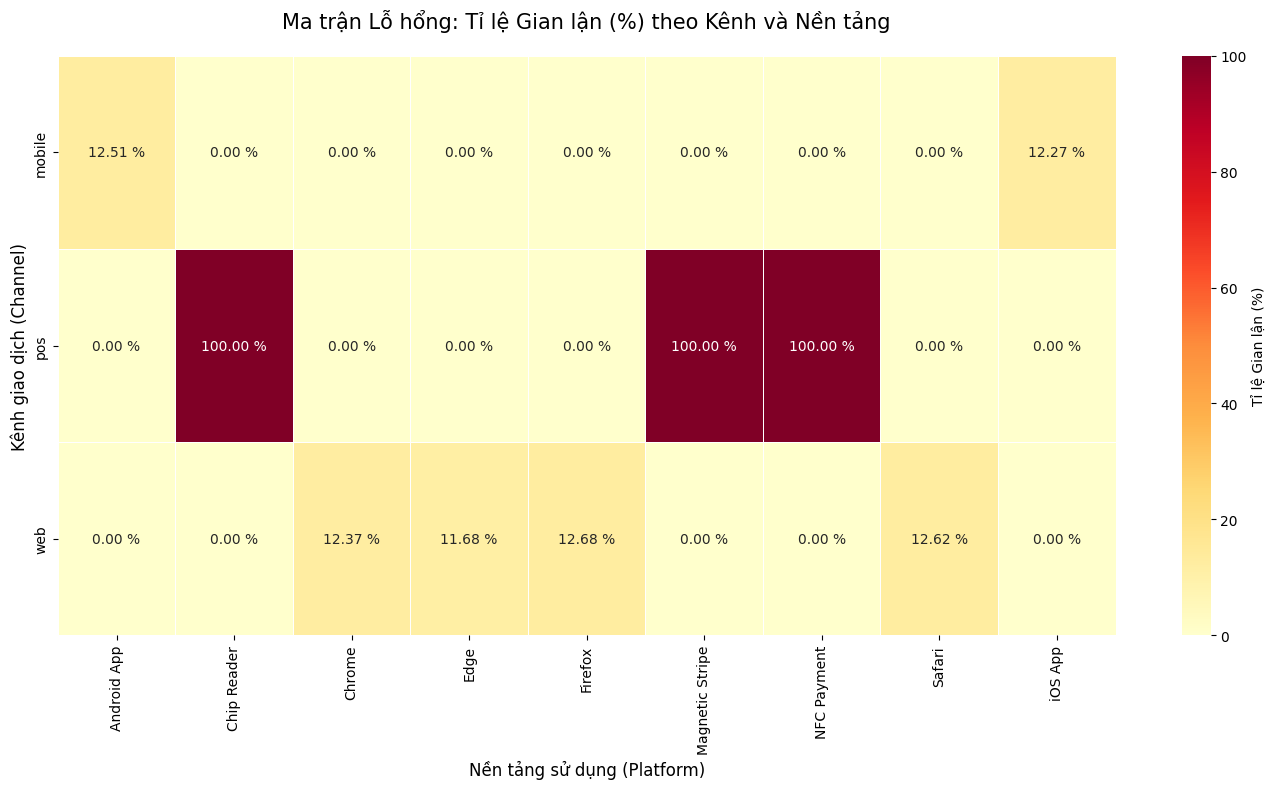

In [ ]:


# 1. Tính tỉ lệ gian lận theo cặp Channel và Platform Used
vulnerability_analysis = (
    df.group_by(["Channel", "Platform Used"])
    .agg(
        (pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate")
    )
    .sort("Fraud_Rate", descending=True)
)

# 2. Chuyển sang Pandas và Pivot để vẽ Heatmap
# Heatmap là lựa chọn tốt nhất để so sánh các cặp giá trị (x, y)
heatmap_data = (
    vulnerability_analysis.to_pandas()
    .pivot(index="Channel", columns="Platform Used", values="Fraud_Rate")
    .fillna(0) # Thay thế các tổ hợp không có giao dịch bằng 0
)

# 3. Vẽ Heatmap
plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", 
    linewidths=.5,
    cbar_kws={'label': 'Tỉ lệ Gian lận (%)'}
)

plt.title('Ma trận Lỗ hổng: Tỉ lệ Gian lận (%) theo Kênh và Nền tảng', fontsize=15, pad=20)
plt.xlabel('Nền tảng sử dụng (Platform)', fontsize=12)
plt.ylabel('Kênh giao dịch (Channel)', fontsize=12)

# Thêm nhãn % vào từng ô để trực quan hơn
for t in ax.texts: 
    t.set_text(t.get_text() + " %")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19104\129664484.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


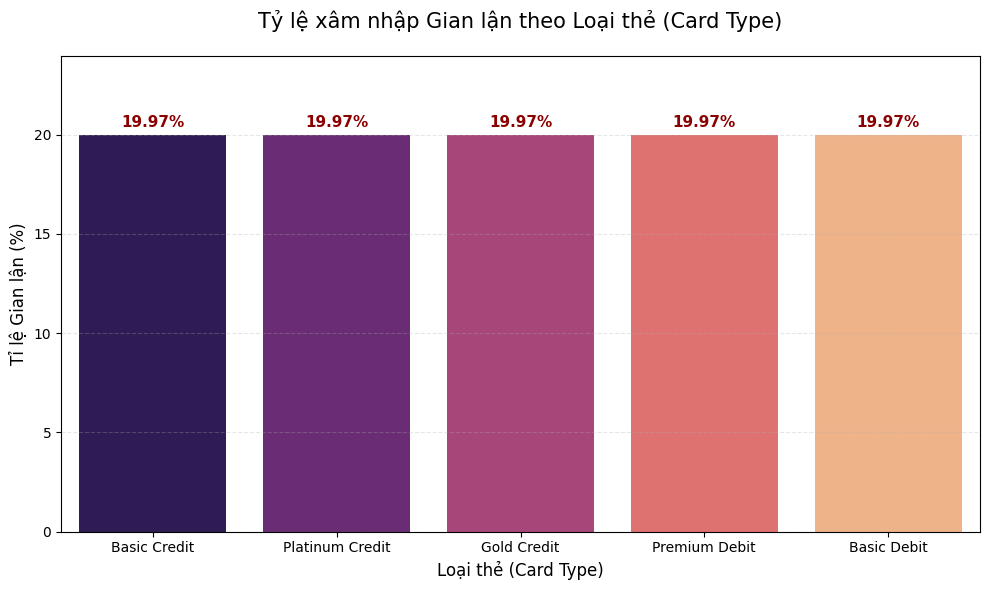

In [ ]:


# 1. Tính toán tỉ lệ gian lận trung bình trên từng loại thẻ
card_fraud_analysis = (
    df.group_by("Card Type")
    .agg(
        (pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate_%")
    )
    .sort("Fraud_Rate_%", descending=True)
)

# 2. Chuyển sang Pandas để vẽ biểu đồ
plot_df = card_fraud_analysis.to_pandas()

# 3. Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df, 
    x='Card Type', 
    y='Fraud_Rate_%', 
    palette='magma'
)

# --- THÊM NHÃN GIÁ TRỊ TRÊN ĐẦU CỘT ---
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            format(p.get_height(), '.2f') + '%', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 9), 
            textcoords='offset points',
            fontsize=11,
            fontweight='bold',
            color='darkred'
        )

# 4. Định dạng biểu đồ
plt.title('Tỷ lệ xâm nhập Gian lận theo Loại thẻ (Card Type)', fontsize=15, pad=20)
plt.xlabel('Loại thẻ (Card Type)', fontsize=12)
plt.ylabel('Tỉ lệ Gian lận (%)', fontsize=12)
plt.ylim(0, plot_df['Fraud_Rate_%'].max() * 1.2) # Tạo khoảng trống cho nhãn
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

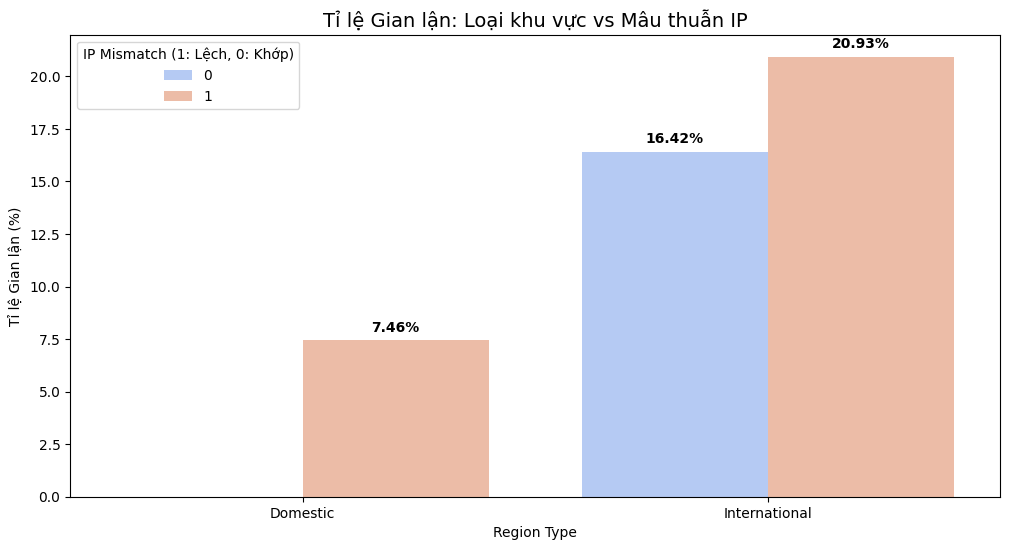

In [ ]:


geo_digital_stats = (
    df.group_by(["Region Type", "Is_IP_Country_Mismatch"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
    .sort("Region Type")
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=geo_digital_stats.to_pandas(), x='Region Type', y='Fraud_Rate', hue='Is_IP_Country_Mismatch', palette='coolwarm')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Tỉ lệ Gian lận: Loại khu vực vs Mâu thuẫn IP', fontsize=14)
plt.ylabel('Tỉ lệ Gian lận (%)')
plt.legend(title='IP Mismatch (1: Lệch, 0: Khớp)')
plt.show()

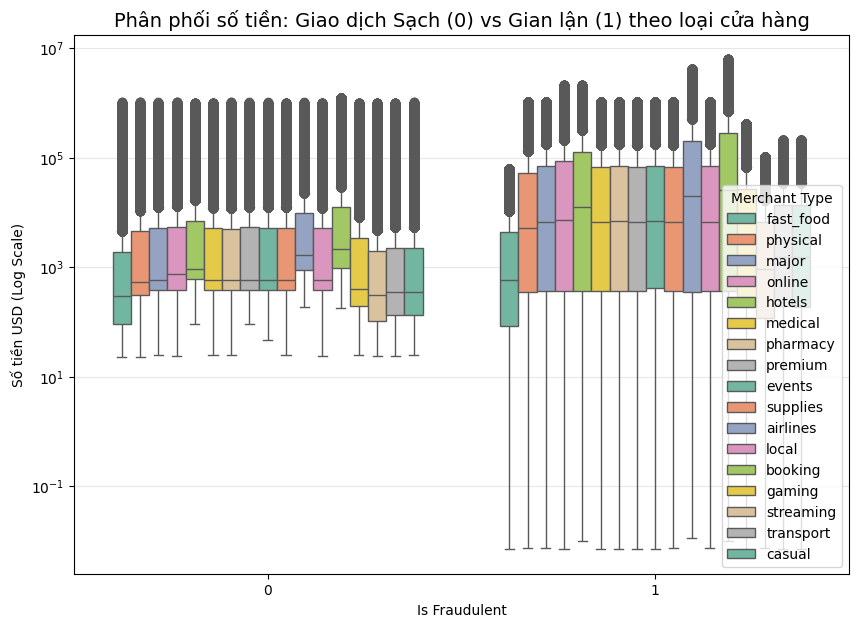

In [12]:
plt.figure(figsize=(10, 7))
# Dùng Boxplot với thang đo Log để quan sát các cực (Outliers) rõ hơn
sns.boxplot(data=df, x='Is Fraudulent', y='Amount USD', hue='Merchant Type', palette='Set2')
plt.yscale('log') 
plt.title('Phân phối số tiền: Giao dịch Sạch (0) vs Gian lận (1) theo loại cửa hàng', fontsize=14)
plt.ylabel('Số tiền USD (Log Scale)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

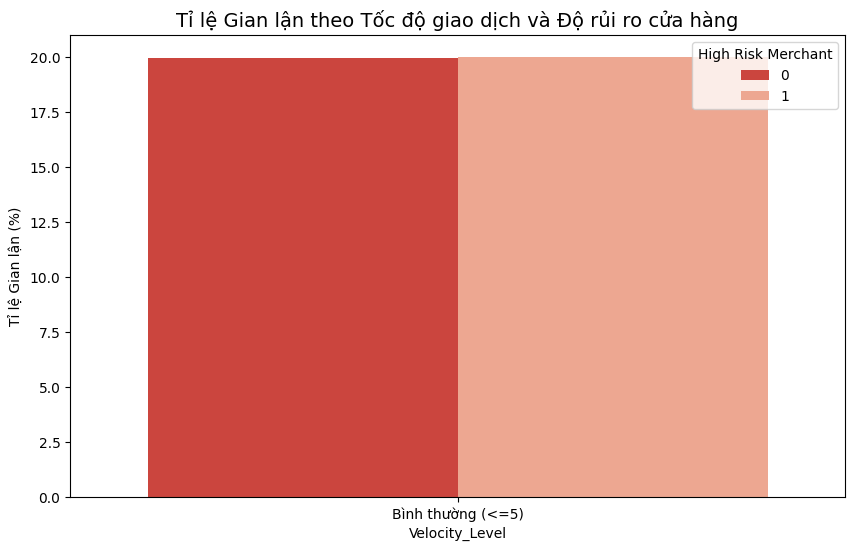

In [13]:
velocity_risk = (
    df.with_columns(
        pl.when(pl.col("Velocity Last Hour") > 5).then(pl.lit("Rất cao (>5)"))
        .otherwise(pl.lit("Bình thường (<=5)")).alias("Velocity_Level")
    )
    .group_by(["Velocity_Level", "High Risk Merchant"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
)

plt.figure(figsize=(10, 6))
sns.barplot(data=velocity_risk.to_pandas(), x='Velocity_Level', y='Fraud_Rate', hue='High Risk Merchant', palette='Reds_r')
plt.title('Tỉ lệ Gian lận theo Tốc độ giao dịch và Độ rủi ro cửa hàng', fontsize=14)
plt.ylabel('Tỉ lệ Gian lận (%)')
plt.show()

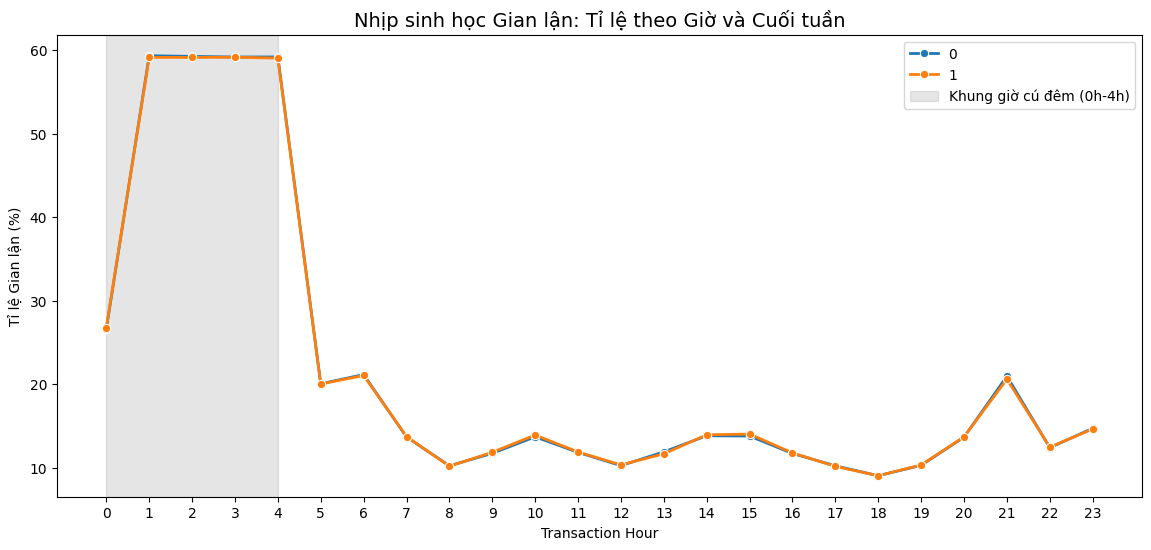

In [14]:
temporal_fraud = (
    df.group_by(["Transaction Hour", "Weekend Transaction"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
    .sort("Transaction Hour")
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=temporal_fraud.to_pandas(), x='Transaction Hour', y='Fraud_Rate', hue='Weekend Transaction', marker='o', linewidth=2)
plt.axvspan(0, 4, color='gray', alpha=0.2, label='Khung giờ cú đêm (0h-4h)')
plt.title('Nhịp sinh học Gian lận: Tỉ lệ theo Giờ và Cuối tuần', fontsize=14)
plt.xticks(range(0, 24))
plt.ylabel('Tỉ lệ Gian lận (%)')
plt.legend()
plt.show()

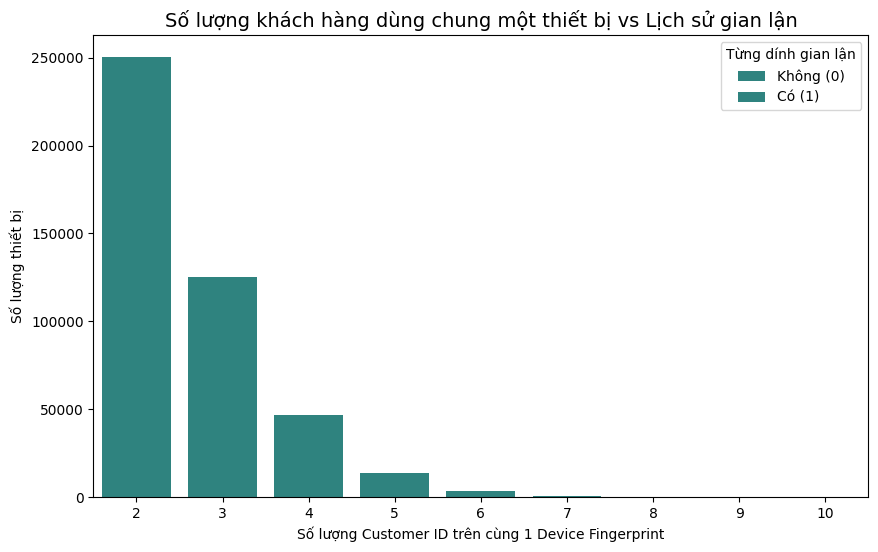

In [15]:
# Đếm số Customer ID trên mỗi Device Fingerprint
device_usage = (
    df.group_by("Device Fingerprint")
    .agg([
        pl.col("Customer ID").n_unique().alias("Unique_Customers"),
        pl.col("Is Fraudulent").max().alias("Any_Fraud") # 1 nếu thiết bị này từng dính gian lận
    ])
    .filter(pl.col("Unique_Customers") > 1) # Chỉ lấy các thiết bị dùng chung
)

plt.figure(figsize=(10, 6))
sns.countplot(data=device_usage.to_pandas(), x='Unique_Customers', hue='Any_Fraud', palette='viridis')
plt.title('Số lượng khách hàng dùng chung một thiết bị vs Lịch sử gian lận', fontsize=14)
plt.xlabel('Số lượng Customer ID trên cùng 1 Device Fingerprint')
plt.ylabel('Số lượng thiết bị')
plt.legend(title='Từng dính gian lận', labels=['Không (0)', 'Có (1)'])
plt.show()

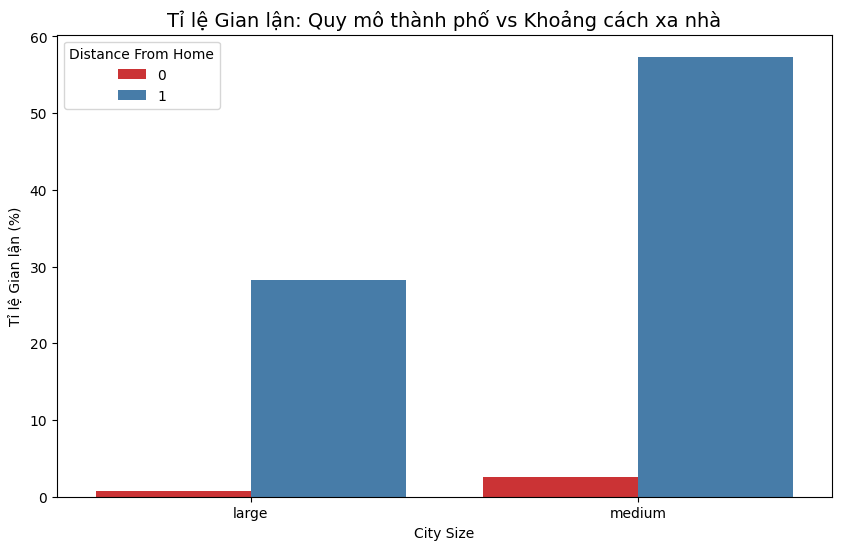

In [16]:
distance_city_fraud = (
    df.group_by(["City Size", "Distance From Home"])
    .agg((pl.col("Is Fraudulent").mean() * 100).alias("Fraud_Rate"))
)

plt.figure(figsize=(10, 6))
sns.barplot(data=distance_city_fraud.to_pandas(), x='City Size', y='Fraud_Rate', hue='Distance From Home', palette='Set1')
plt.title('Tỉ lệ Gian lận: Quy mô thành phố vs Khoảng cách xa nhà', fontsize=14)
plt.ylabel('Tỉ lệ Gian lận (%)')
plt.show()

In [20]:
df.schema

Schema([('Transaction ID', String),
        ('Customer ID', String),
        ('Card Number', Int64),
        ('Transaction Date', String),
        ('Product Category', String),
        ('Merchant Type', String),
        ('Merchant', String),
        ('Currency', String),
        ('Country', String),
        ('City', String),
        ('City Size', String),
        ('Card Type', String),
        ('Card Present', Int64),
        ('Channel', String),
        ('Device Fingerprint', String),
        ('IP Address', String),
        ('Distance From Home', Int64),
        ('High Risk Merchant', Int64),
        ('Transaction Hour', Int64),
        ('Weekend Transaction', Int64),
        ('Velocity Last Hour', Float64),
        ('Is Fraudulent', Int64),
        ('Transaction Year', Int64),
        ('Transaction Month', Int64),
        ('Transaction Week', Int64),
        ('Channel_Error', Boolean),
        ('Category_Error', Boolean),
        ('Region Type', String),
        ('Platform Used', Str

In [2]:
# Cách viết chuẩn trong Polars
cols_to_drop = ['Transaction ID', 'Customer ID', 'IP Address', 'Channel_Error', 'Category_Error']

# Kiểm tra xem các cột có tồn tại trước khi drop để tránh lỗi KeyError
df = df.drop([col for col in cols_to_drop if col in df.columns])

print(f"Số cột còn lại sau khi drop: {df.width}")

Số cột còn lại sau khi drop: 27


### CHIA TRAIN TEST VALID

In [3]:
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(
    df.to_pandas(), 
    test_size=0.15, 
    stratify=df['Is Fraudulent'].to_numpy(),
    random_state=42
)

# Bước 2: Chia 85% phía trên thành Train và Val
# Để có 10% tổng dữ liệu từ 85%, ta cần lấy: 10 / 85 = 0.1176 (xấp xỉ 11.76%)
train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.1176, 
    stratify=train_val_df['Is Fraudulent'],
    random_state=42
)

# Bước 3: Lưu thành các file CSV bằng Polars (để xử lý nhanh và nén tốt)
pl.from_pandas(train_df).write_csv("train_75.csv")
pl.from_pandas(val_df).write_csv("val_10.csv")
pl.from_pandas(test_df).write_csv("test_15.csv")

# Kiểm tra lại kích thước
print(f"Kích thước Train (75%): {len(train_df):,} dòng")
print(f"Kích thước Val   (10%): {len(val_df):,} dòng")
print(f"Kích thước Test  (15%): {len(test_df):,} dòng")

Kích thước Train (75%): 5,613,123 dòng
Kích thước Val   (10%): 748,078 dòng
Kích thước Test  (15%): 1,122,565 dòng
